In [1]:
import redback 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
15:13 bilby INFO    : Running bilby version: 2.3.0
15:13 redback INFO    : Running redback version: 1.12.1


In [2]:
def sn1998bw_template(time, redshift, amplitude, **kwargs):
    """
    A wrapper to the SN1998bw template. Only valid between 1100-11000 Angstrom and 0.01 to 90 days post explosion in rest frame

    Parameters
    ----------
    time
        time in days in observer frame (post explosion)
    redshift
        redshift
    amplitude
        amplitude scaling factor, where 1.0 is the original brightness of SN1998bw; and f_lambda is scaled by this factor
    kwargs
        Additional keyword arguments required by redback.
    frequency
        Required if output_format is 'flux_density'. frequency to calculate - Must be same length as time array or a single number).
    bands
        Required if output_format is 'magnitude' or 'flux'.
    output_format
        'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'
    cosmology
        Cosmology to use for luminosity distance calculation. Defaults to Planck18. Must be a astropy.cosmology object.
    Returns
    -------
        set by output format - 'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'

    """
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    tts = np.geomspace(0.01, 90, 200)
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(tts, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = tts * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)

In [3]:
# After pasting the function definition into your cell:
from redback.model_library import all_models_dict

all_models_dict['sn1998bw_template'] = sn1998bw_template

# Now any redback functions that look in the dictionary will find it!

In [4]:
func = all_models_dict['sn1998bw_template']

time = np.array((90)) #worked for np.array([11]) so works for all other times ?
red = 0.0085 #redshift of arbitrary event (in this case we just wanted f_1998bw = 1 )
freq = 3e14 #lower limit = 2.75e14 - if 2.0e14 does this give inf ?? YES - BE VERY CAREFUOL WITH THE FREQUENCY RANGES !! 

sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)
sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)

print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

[0.12421773] [0.12421773] [1.]


In [5]:
#THIS WORKS !! ???!!! WHEN z = 0.085, but when z = 0.0085(tru redshift) model is still correct !! YAY 

#BETWEEN FREQUENCIES 3E14 - 1E15 THIS RETURNS F_98 VALUE WHICH IS CORRECT !! 
#DOES THIS WORK FOR ALL TIMES ? SHOULD DO !  works at anothing from 0.02 and above upto 90 (95)

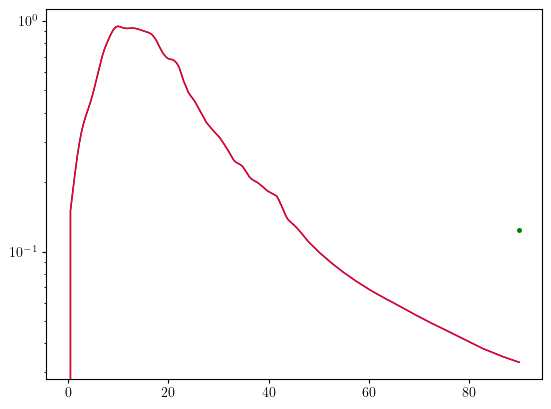

In [6]:
#Print out a graph of the lightcurve to check what is going on: 
#TESTING TO GET F_98 = 1 !! 

#WHAT FREQUENCY GETS THIS TO B F_98 = 1? 
#use jillians values ? 
freq = 1e15
redshift = 0.0085
times = np.linspace(0.01,90,200)
sn_1998bw = func(time=times,redshift=redshift,amplitude=1.0,output_format='flux_density',frequency=freq)
sn_1998bw1 = func(time=times,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density')

plt.semilogy(times,sn_1998bw,'-b')
plt.semilogy(times,sn_1998bw1, '-r')
#this point is the arbitrary GRB event at the epoch 
plt.semilogy(time,sn_1998b1, marker='o',color='green')
#plt.ylim(19,13)
plt.show()

In [12]:
#now test against an actual observed flux density of 980425 not just what the model predicts the flux density to be: 
#from Jillian's data take a datapoint at late time for 1998bw's GRB (presume it is extinction corrected): 20.46999999988824,V,n/a,13.92,0.06

#have to use AB mangitude filters if i can !! 
#convert
#10.420000000074506,Rc,n/a,14.23,0.05

event_name = '980425'
AB_mag = 14.23 + 0.21 #Rc correction --> AB_mag -- larger han the set peak in thecode ! what does thias mean ??
redshift = 0.0085
epoch = np.array([10.420000000074506]) # Days in observer frame
a_v = 0.059
frequency = 4.61700e+14 #R 
wavelength = np.array([6498.09000]) #angstroms

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print("This is the flux density of  GRB event", event_name ,f"without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event)
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")


func = all_models_dict['sn1998bw_template']

time = epoch 
red = redshift 
freq = frequency

sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #artibtrary GRB
sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo) #SN1998bw

#which result is more similar to andrew ? 
#using model - no extinction 
print(sn_1998b2, sn_1998b1, sn_1998b1/sn_1998b2)

#extinction corrected flux frac: 
print(f"{dereddened_flux_event[0]:.5f}", sn_1998b2, dereddened_flux_event[0]/sn_1998b2) #sn_1998b2 NOT sn_1998b1 since sn_1998b2 = correct interpolation of 1998bw

#OK SO WHEN I RUN THIS THROUGH THE MODEL AND LET THE MODEL OUTPUT A FLUX DENSITY - IT WORKS - ISH, BUT WHEN I DONT LET THE MODEL DO IT AND I USE A FLUX DENSITY WHICH I FIND MYSELF, IT DOESNT WORK 
#IS THIS TRUE FOR OTHER EVENTS ? 

This is the flux density of  GRB event 980425 without extinction correction: 6.08135 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 6.34189 mJy
[9.48675333] [9.48675333] [1.]
6.34189 mJy [9.48675333] [0.66849971] mJy
